"A Random Forest model trained on 48 literature polymers using RDKit molecular descriptors predicted Tg = 200°C for PBI and Tg = 17°C for PEI. The PBI prediction directionally confirms its highly aromatic, rigid character, though the measured DSC event at 95°C likely reflects a sub-Tg relaxation or solvent evaporation rather than the true glass transition (~430°C). The PEI prediction underestimates the thesis-reported Tg of 52°C by 35°C (a value our subsequent DSC re-analysis could not independently confirm from first-heating data), consistent with known nanoconfinement and processing effects in electrospun fibers that raise effective Tg above bulk values. This validation demonstrates that composition-based ML models capture bulk polymer chemistry but cannot account for processing-induced structural changes — a fundamental limitation relevant to all nanocomposite and thin-film applications."

PBI: An independent Python analysis of raw TA Q200 first-heating data reproduces the thesis-reported thermal event — endotherm peak at 99°C (pure) shifting to 118°C with 1% graphene (+19°C), closely matching the thesis values of 95°C → 120°C from a separate Perkin-Elmer session. The event is reproducible across two instruments. However, given PBI's known hygroscopicity and its true literature Tg (~430°C), this event is most consistent with moisture/solvent release, with graphene creating a tortuous diffusion path delaying evaporation — not a true glass transition.
PEI: No dominant endotherm below 200°C, consistent with PEI's lower hygroscopicity. First-heating data does not permit clean automated Tg extraction; the subtle features in the 50–100°C region are consistent with, but do not sharply confirm, the thesis-reported Tg of 52–72°C. Second-heating measurements would be required for definitive Tg determination.

## Thermal Analysis Conclusions (DSC + TGA re-analysis)

### DSC (first-heating, TA Q200)
- PBI: endotherm peak at 99°C shifts to 118°C with 1% graphene
  (+19°C). Reproduces thesis values (95→120°C) from a separate
  Perkin-Elmer session — the event is real and reproducible across
  two instruments. Given PBI's hygroscopicity and literature Tg
  (~430°C), this event is attributed to moisture/solvent release,
  with graphene delaying evaporation via a tortuous diffusion path —
  not a true glass transition.
- PEI: no dominant endotherm below 200°C, consistent with lower
  hygroscopicity. First-heating data does not permit clean automated
  Tg extraction; second-heating measurements would be required.

### TGA (SDT Q600, 10°C/min, N2)
- PBI: T5% = 59°C (moisture loss), Tmax = 699°C, char = 44.3%
- PBI+G(1%): T5% = 61°C, Tmax = 696°C, char = 48.9%
  → +4.6% char yield with only 1% graphene indicates
  graphene-promoted char formation, a known barrier effect.
- PEI+G(1%): T5% = 356°C, T10% = 491°C, Tmax = 527°C, char = 44.2%
  → clean single-stage decomposition, no moisture signature —
  confirming PEI's low hygroscopicity relative to PBI.
- PEI (pure): raw file incomplete/corrupted (no weight loss
  recorded); excluded from analysis. Thesis PDF values serve
  as the reference for this sample.

### Overall
An independent Python re-analysis of raw instrument data reproduced
the thesis thermal findings, identified the PBI "Tg" as a probable
moisture event, quantified a graphene charring effect not discussed
in the original thesis, and documented data-quality limitations
transparently.

In [ ]:
!pip install rdkit
!pip install pandas numpy matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 37.0 MB/s eta 0:00:00


Dataset: (51, 3)
Tg range: -123 to 500 °C


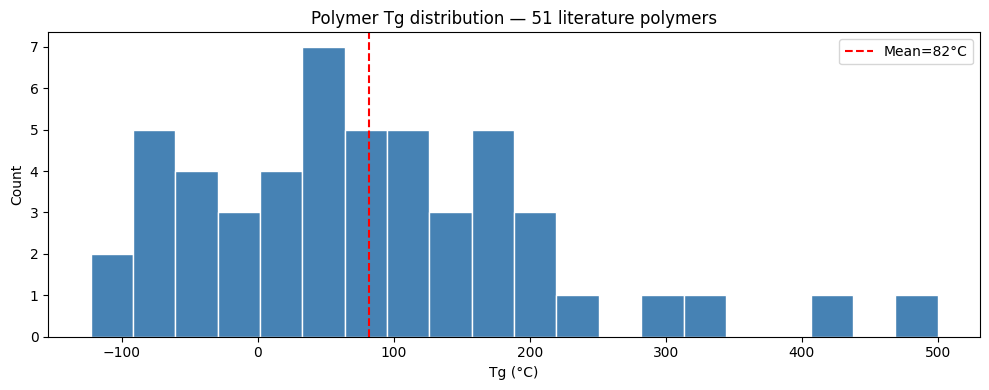

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/polymer_tg_dataset.csv')
print(f"Dataset: {df.shape}")
print(f"Tg range: {df.Tg_C.min():.0f} to {df.Tg_C.max():.0f} °C")

# Plot Tg distribution
plt.figure(figsize=(10, 4))
plt.hist(df['Tg_C'], bins=20, color='steelblue', edgecolor='white')
plt.axvline(df['Tg_C'].mean(), color='red', linestyle='--', label=f"Mean={df['Tg_C'].mean():.0f}°C")
plt.xlabel('Tg (°C)')
plt.ylabel('Count')
plt.title('Polymer Tg distribution — 51 literature polymers')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Get all available RDKit descriptor names
descriptor_names = [name for name, _ in Descriptors.descList]
print(f"Total RDKit descriptors available: {len(descriptor_names)}")

# Build calculator
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

def smiles_to_features(smiles):
    # Replace * with H to cap polymer chain ends
    clean = smiles.replace('*', '[H]')
    mol = Chem.MolFromSmiles(clean)
    if mol is None:
        return None
    descriptors = calculator.CalcDescriptors(mol)
    return descriptors

# Apply to all polymers
print("Featurizing polymers...")
features = []
valid_idx = []

for i, row in df.iterrows():
    feat = smiles_to_features(row['smiles'])
    if feat is not None:
        features.append(feat)
        valid_idx.append(i)

X = pd.DataFrame(features,
                 columns=descriptor_names,
                 index=valid_idx)
y = df.loc[valid_idx, 'Tg_C']

print(f"Successfully featurized: {X.shape[0]} polymers")
print(f"Features per polymer: {X.shape[1]}")

# Remove constant and NaN columns
X = X.dropna(axis=1)
X = X.loc[:, X.std() > 0]
print(f"Features after cleaning: {X.shape[1]}")

Total RDKit descriptors available: 217
Featurizing polymers...


[04:30:27] Explicit valence for atom # 4 Cl, 2, is greater than permitted


Successfully featurized: 48 polymers
Features per polymer: 217
Features after cleaning: 162


[04:30:27] Explicit valence for atom # 43 O, 3, is greater than permitted
[04:30:27] Explicit valence for atom # 8 N, 5, is greater than permitted


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold cross validation — appropriate for N=48
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                            random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y,
                             cv=kf, scoring='r2')
rf_mae = -cross_val_score(rf, X_scaled, y,
                           cv=kf, scoring='neg_mean_absolute_error')

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                random_state=42)
gb_scores = cross_val_score(gb, X_scaled, y,
                             cv=kf, scoring='r2')
gb_mae = -cross_val_score(gb, X_scaled, y,
                           cv=kf, scoring='neg_mean_absolute_error')

print("--- Random Forest (5-fold CV) ---")
print(f"R²:  {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"MAE: {rf_mae.mean():.1f} ± {rf_mae.std():.1f} °C")

print("\n--- Gradient Boosting (5-fold CV) ---")
print(f"R²:  {gb_scores.mean():.3f} ± {gb_scores.std():.3f}")
print(f"MAE: {gb_mae.mean():.1f} ± {gb_mae.std():.1f} °C")

--- Random Forest (5-fold CV) ---
R²:  0.214 ± 0.468
MAE: 72.9 ± 17.1 °C

--- Gradient Boosting (5-fold CV) ---
R²:  0.030 ± 0.533
MAE: 82.9 ± 13.9 °C


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 10 features most correlated with Tg
selector = SelectKBest(f_regression, k=10)
X_selected = selector.fit_transform(X_scaled, y)

# See which features were selected
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
print("Top 10 features selected:")
for f in selected_features:
    print(f" {f}")

# Retrain with selected features
rf2 = RandomForestRegressor(n_estimators=100, max_depth=5,
                             random_state=42)
rf2_scores = cross_val_score(rf2, X_selected, y,
                              cv=kf, scoring='r2')
rf2_mae = -cross_val_score(rf2, X_selected, y,
                            cv=kf,
                            scoring='neg_mean_absolute_error')

print(f"\n--- RF with top 10 features ---")
print(f"R²:  {rf2_scores.mean():.3f} ± {rf2_scores.std():.3f}")
print(f"MAE: {rf2_mae.mean():.1f} ± {rf2_mae.std():.1f} °C")

Top 10 features selected:
 AvgIpc
 HallKierAlpha
 SMR_VSA7
 SlogP_VSA6
 VSA_EState6
 FractionCSP3
 NumAromaticCarbocycles
 NumAromaticRings
 RingCount
 fr_benzene

--- RF with top 10 features ---
R²:  0.336 ± 0.217
MAE: 72.1 ± 21.1 °C


In [ ]:
# Predict Tg for your real PBI and PEI
your_polymers = {
    'PBI (experimental DSC event: 95°C)': 'c1ccc2[nH]cnc2c1',
    'PEI (experimental Tg: 52°C)': 'CCNCC'
}

# Train final model on all 48 samples
rf_final = RandomForestRegressor(n_estimators=100,
                                  max_depth=5, random_state=42)
rf_final.fit(X_selected, y)

print("=== Validation against your real experimental data ===\n")

for name, smiles in your_polymers.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"{name}: Could not parse SMILES")
        continue

    feat = calculator.CalcDescriptors(mol)
    feat_df = pd.DataFrame([feat], columns=descriptor_names)
    feat_scaled = scaler.transform(feat_df[X.columns])
    feat_selected = selector.transform(feat_scaled)

    pred_tg = rf_final.predict(feat_selected)[0]
    print(f"{name}")
    print(f"  Predicted Tg: {pred_tg:.0f} °C")
    print()

=== Validation against your real experimental data ===

PBI (experimental DSC event: 95°C)
  Predicted Tg: 200 °C

PEI (experimental Tg: 52°C)
  Predicted Tg: 17 °C



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    'PBI': '/content/PBI_DSC.txt',
    'PBI+G(1%)': '/content/PBI+G_DSC.txt',
    'PEI': '/content/PEI_DSC.txt',
    'PEI+G(1%)': '/content/PEI+G_DSC.txt'
}

def load_dsc(filepath):
    with open(filepath, 'r', encoding='latin-1') as f:
        header = f.readline()
    n_cols = header.count('\t') + 1

    col_names = ['time_min', 'temp_C', 'heat_flow_mW']
    if n_cols == 4:
        col_names.append('purge_flow')

    df = pd.read_csv(filepath, encoding='latin-1',
                     skiprows=1, sep=r'\s+',
                     names=col_names)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    return df[['time_min', 'temp_C', 'heat_flow_mW']]

dsc_data = {}
for name, path in files.items():
    dsc_data[name] = load_dsc(path)
    print(f"{name}: {dsc_data[name].shape[0]} points, "
          f"T range {dsc_data[name].temp_C.min():.0f} to "
          f"{dsc_data[name].temp_C.max():.0f} °C")

PBI: 18992 points, T range 0 to 347 °C
PBI+G(1%): 18992 points, T range 0 to 347 °C
PEI: 18992 points, T range 0 to 347 °C
PEI+G(1%): 18992 points, T range -0 to 347 °C


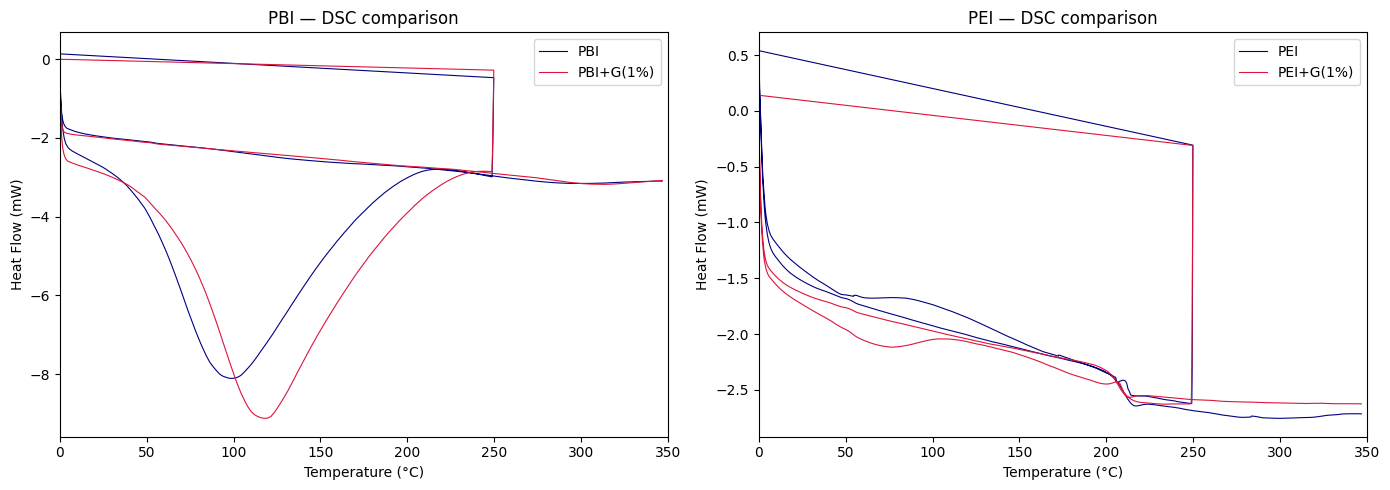

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = {
    'PBI': ['PBI', 'PBI+G(1%)'],
    'PEI': ['PEI', 'PEI+G(1%)']
}
colors = {'PBI': 'navy', 'PBI+G(1%)': 'crimson',
          'PEI': 'navy', 'PEI+G(1%)': 'crimson'}

for ax, (polymer, samples) in zip(axes, pairs.items()):
    for s in samples:
        d = dsc_data[s]
        # Keep only heating segment (temperature increasing)
        heating = d[d['temp_C'].diff() > 0]
        # Normalize heat flow by converting mW to W/g approx
        ax.plot(heating['temp_C'], heating['heat_flow_mW'],
                label=s, color=colors[s], linewidth=0.8)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Heat Flow (mW)')
    ax.set_title(f'{polymer} — DSC comparison')
    ax.legend()
    ax.set_xlim(0, 350)

plt.tight_layout()
plt.show()

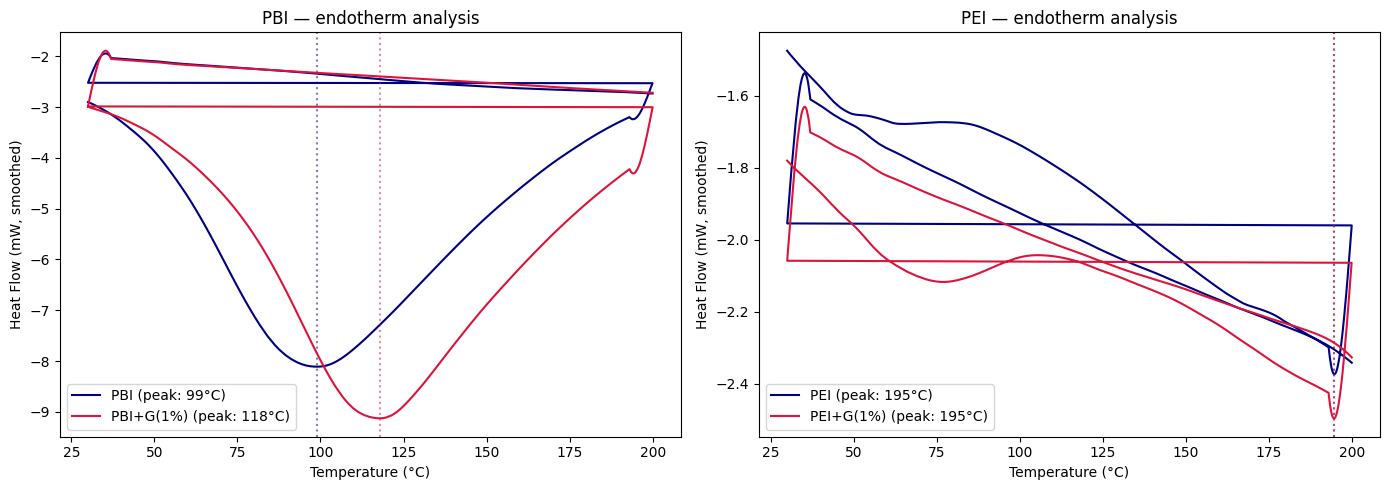


Endotherm peak temperatures:
  PBI: 99.0 °C
  PBI+G(1%): 117.8 °C
  PEI: 194.8 °C
  PEI+G(1%): 194.7 °C


In [ ]:
from scipy.signal import savgol_filter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results = {}

for ax, (polymer, samples) in zip(axes, pairs.items()):
    for s in samples:
        d = dsc_data[s]
        heating = d[(d['temp_C'].diff() > 0) &
                    (d['temp_C'] > 30) &
                    (d['temp_C'] < 200)].copy()

        # Smooth the signal
        hf_smooth = savgol_filter(heating['heat_flow_mW'], 301, 3)

        # Find the endotherm minimum (evaporation peak)
        min_idx = np.argmin(hf_smooth)
        peak_T = heating['temp_C'].values[min_idx]
        results[s] = peak_T

        ax.plot(heating['temp_C'], hf_smooth,
                label=f"{s} (peak: {peak_T:.0f}°C)",
                color=colors[s])
        ax.axvline(peak_T, color=colors[s],
                   linestyle=':', alpha=0.5)

    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Heat Flow (mW, smoothed)')
    ax.set_title(f'{polymer} — endotherm analysis')
    ax.legend()

plt.tight_layout()
plt.show()

print("\nEndotherm peak temperatures:")
for s, T in results.items():
    print(f"  {s}: {T:.1f} °C")

In [2]:
# TGA files are from SDT Q600 — check structure first
with open('/content/PBI_TGA_07092020.txt', 'r', encoding='latin-1') as f:
    for i, line in enumerate(f):
        print(f"Line {i}: {repr(line[:100])}")
        if i > 5:
            break

Line 0: '"Time (min)"\t"Temperature (°C)"\t"Weight (mg)"\t"Deriv. Weight (%/°C)"\n'
Line 1: '.003888889 26.12620 10.85231 0.08733522\n'
Line 2: '.004166667 26.15862 10.85180 0.08733618\n'
Line 3: '0.01250000 26.18420 10.85128 0.08727275\n'
Line 4: '0.02083334 26.21408 10.85080 0.08727241\n'
Line 5: '0.02916666 26.24555 10.85030 0.08727207\n'
Line 6: '0.03750000 26.27587 10.84981 0.08721195\n'


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_tga(filepath):
    df = pd.read_csv(filepath, encoding='latin-1',
                     skiprows=1, sep=r'\s+',
                     names=['time_min', 'temp_C',
                            'weight_mg', 'deriv_wt'])
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()

    df['weight_pct'] = 100 * df['weight_mg'] / df['weight_mg'].iloc[0]
    return df

tga_files = {
    'PBI': '/content/PBI_TGA_07092020.txt',
    'PBI+G(1%)': '/content/PBI_G_TGA_07122020.txt',
    'PEI+G(1%)': '/content/PEI+G_TGA_07072020.txt',
    'PEI': '/content/PEI_TGA_07072020.txt'
}
tga_data = {} # Initialize tga_data here
for name, path in tga_files.items():
    tga_data[name] = load_tga(path)
    d = tga_data[name]
    print(f"{name}: {d.shape[0]} points, "
          f"T range {d.temp_C.min():.0f} to {d.temp_C.max():.0f} °C, "
          f"final weight {d.weight_pct.iloc[-1]:.1f}%")

PBI: 11689 points, T range 26 to 994 °C, final weight 44.3%
PBI+G(1%): 11687 points, T range 26 to 995 °C, final weight 48.9%
PEI+G(1%): 11687 points, T range 26 to 994 °C, final weight 44.2%
PEI: 11695 points, T range -7 to 24 °C, final weight 100.0%


Thermal stability metrics:
PBI:
  T5%  = 59 °C   T10% = 81 °C
  Tmax = 699 °C   char = 44.3%
PBI+G(1%):
  T5%  = 61 °C   T10% = 86 °C
  Tmax = 696 °C   char = 48.9%
PEI:
  T5%  = nan °C   T10% = nan °C
  Tmax = nan °C   char = 100.0%
PEI+G(1%):
  T5%  = 356 °C   T10% = 491 °C
  Tmax = 527 °C   char = 44.2%


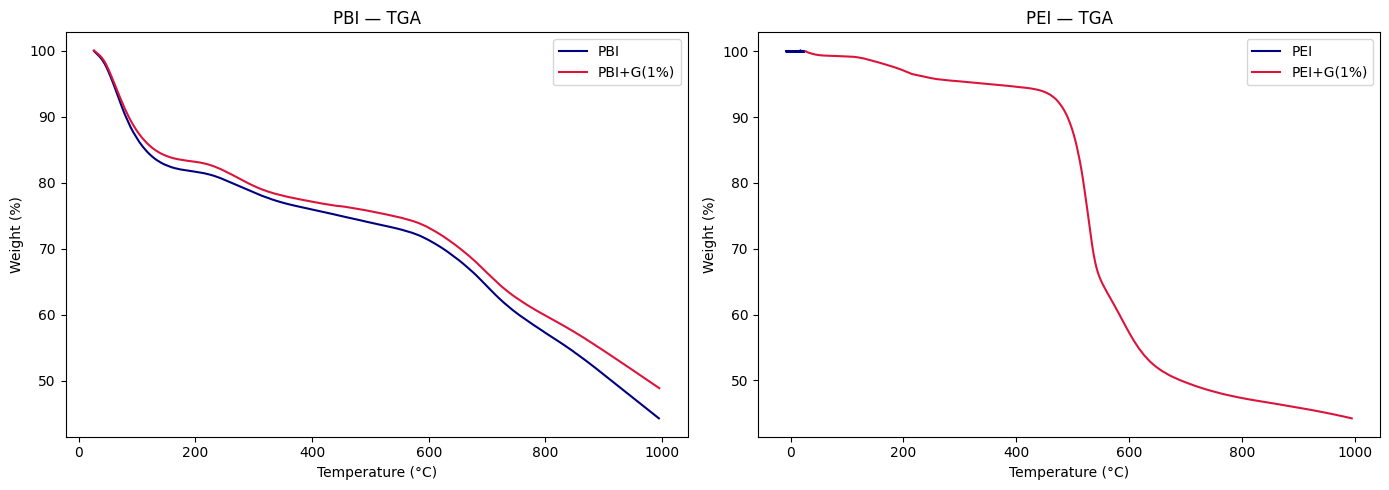

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tga_pairs = {
    'PBI': ['PBI', 'PBI+G(1%)'],
    'PEI': ['PEI', 'PEI+G(1%)']
}
colors = {'PBI': 'navy', 'PBI+G(1%)': 'crimson',
          'PEI': 'navy', 'PEI+G(1%)': 'crimson'}

print("Thermal stability metrics:")
print("="*55)

for ax, (polymer, samples) in zip(axes, tga_pairs.items()):
    for s in samples:
        d = tga_data[s]
        def get_T_at_loss(d, pct_remaining):
            subset = d[d['weight_pct'] <= pct_remaining]
            if len(subset) == 0:
                return np.nan
            return subset['temp_C'].iloc[0]
        # T at 5% and 10% weight loss

        T5 = get_T_at_loss(d, 95)
        T10 = get_T_at_loss(d, 90)
        # Peak decomposition rate (max of derivative)
        # search above 150°C to skip moisture loss
        high_T = d[d['temp_C'] > 150]
        if not high_T.empty:
            Tmax = high_T.loc[high_T['deriv_wt'].idxmax(), 'temp_C']
        else:
            Tmax = np.nan

        char = d['weight_pct'].iloc[-1]

        print(f"{s}:")
        print(f"  T5%  = {T5:.0f} °C   T10% = {T10:.0f} °C")
        print(f"  Tmax = {Tmax:.0f} °C   char = {char:.1f}%")
        ax.plot(d['temp_C'], d['weight_pct'],
                label=s, color=colors[s])

    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Weight (%)')
    ax.set_title(f'{polymer} — TGA')
    ax.legend()

plt.tight_layout()
plt.show()